In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Data referensi — kendaraan Toyota & negara tujuan
vehicles  = ['Kijang Innova','Fortuner','Rush','Avanza','Calya','Raize']
countries = ['Indonesia','Malaysia','Thailand','Australia','Vietnam','Philippines']
reg_categories = {
    'Emission Standard'  : ['Euro 2','Euro 4','Euro 6'],
    'Brake System'       : ['UN R13','UN R13H'],
    'Safety Belt'        : ['UN R16','UN R94'],
    'Crash Test'         : ['ASEAN NCAP','Euro NCAP','ANCAP'],
    'Noise Level'        : ['UN R51.03'],
    'Exterior Lighting'  : ['UN R48','DRL Requirement'],
    'Fuel Economy Label' : ['Country Specific']
}

# Buat dataset
data = []
for vehicle in vehicles:
    for country in countries:
        for reg_cat, reg_codes in reg_categories.items():
            reg_code = np.random.choice(reg_codes)
            status   = np.random.choice(
                ['Compliant','Non-Compliant','Pending Review','Under Validation'],
                p=[0.60, 0.12, 0.18, 0.10]
            )
            last_upd    = pd.Timestamp('2024-06-01') + pd.Timedelta(days=int(np.random.randint(0,300)))
            next_review = last_upd + pd.Timedelta(days=int(np.random.randint(90,365)))
            data.append({
                'Vehicle Model'     : vehicle,
                'Destination Country': country,
                'Regulation Category': reg_cat,
                'Regulation Code'   : reg_code,
                'Status'            : status,
                'Last Updated'      : last_upd.strftime('%Y-%m-%d'),
                'Next Review Date'  : next_review.strftime('%Y-%m-%d'),
                'Responsible Dept'  : np.random.choice(['Engineering','Compliance','R&D','Quality']),
                'Remarks'           : ''
            })

df = pd.DataFrame(data)
df.to_csv('vehicle_regulation_compliance.csv', index=False)

print(f"Dataset selesai dibuat: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"\nDistribusi status:")
print(df['Status'].value_counts())
print(f"\n5 baris pertama:")
df.head()

Dataset selesai dibuat: 252 baris x 9 kolom

Distribusi status:
Status
Compliant           155
Pending Review       40
Non-Compliant        35
Under Validation     22
Name: count, dtype: int64

5 baris pertama:


,Vehicle Model,Destination Country,Regulation Category,Regulation Code,Status,Last Updated,Next Review Date,Responsible Dept,Remarks
0,Kijang Innova,Indonesia,Emission Standard,Euro 6,Pending Review,2025-02-26,2025-09-10,Quality,
1,Kijang Innova,Indonesia,Brake System,UN R13,Compliant,2024-09-30,2025-07-31,R&D,
2,Kijang Innova,Indonesia,Safety Belt,UN R16,Pending Review,2024-09-08,2025-05-07,R&D,
3,Kijang Innova,Indonesia,Crash Test,Euro NCAP,Compliant,2025-03-21,2025-12-27,Quality,
4,Kijang Innova,Indonesia,Noise Level,UN R51.03,Compliant,2024-06-22,2025-05-30,Quality,


In [2]:
# Compliance rate per negara
print("=== COMPLIANCE RATE PER NEGARA ===")
country_stats = df.groupby(['Destination Country','Status']).size().unstack(fill_value=0)
country_stats['Total'] = country_stats.sum(axis=1)
country_stats['Compliance Rate (%)'] = (
    country_stats.get('Compliant',0) / country_stats['Total'] * 100
).round(1)
print(country_stats[['Compliant','Non-Compliant','Pending Review','Compliance Rate (%)']
                    ].sort_values('Compliance Rate (%)', ascending=False))

# Item non-compliant — ini yang paling penting di pekerjaan nyata
print("\n=== ITEM NON-COMPLIANT (Perlu Tindakan Segera) ===")
non_compliant = df[df['Status']=='Non-Compliant'][[
    'Vehicle Model','Destination Country','Regulation Category',
    'Regulation Code','Next Review Date','Responsible Dept'
]].sort_values('Next Review Date').reset_index(drop=True)
print(f"Total: {len(non_compliant)} item memerlukan tindakan")
print(non_compliant.to_string())

# Ringkasan per kendaraan
print("\n=== COMPLIANCE RATE PER KENDARAAN ===")
v_stats = df.groupby(['Vehicle Model','Status']).size().unstack(fill_value=0)
v_stats['Compliance Rate (%)'] = (
    v_stats.get('Compliant',0) / v_stats.sum(axis=1) * 100
).round(1)
print(v_stats[['Compliance Rate (%)']].sort_values('Compliance Rate (%)',ascending=False))

=== COMPLIANCE RATE PER NEGARA ===
Status               Compliant  Non-Compliant  Pending Review  \
Destination Country                                             
Indonesia                   29              5               7   
Philippines                 27              7               5   
Australia                   26              7               5   
Thailand                    26              3               6   
Vietnam                     26              5              10   
Malaysia                    21              8               7   

Status               Compliance Rate (%)  
Destination Country                       
Indonesia                           69.0  
Philippines                         64.3  
Australia                           61.9  
Thailand                            61.9  
Vietnam                             61.9  
Malaysia                            50.0  

=== ITEM NON-COMPLIANT (Perlu Tindakan Segera) ===
Total: 35 item memerlukan tindakan
    Vehicle M

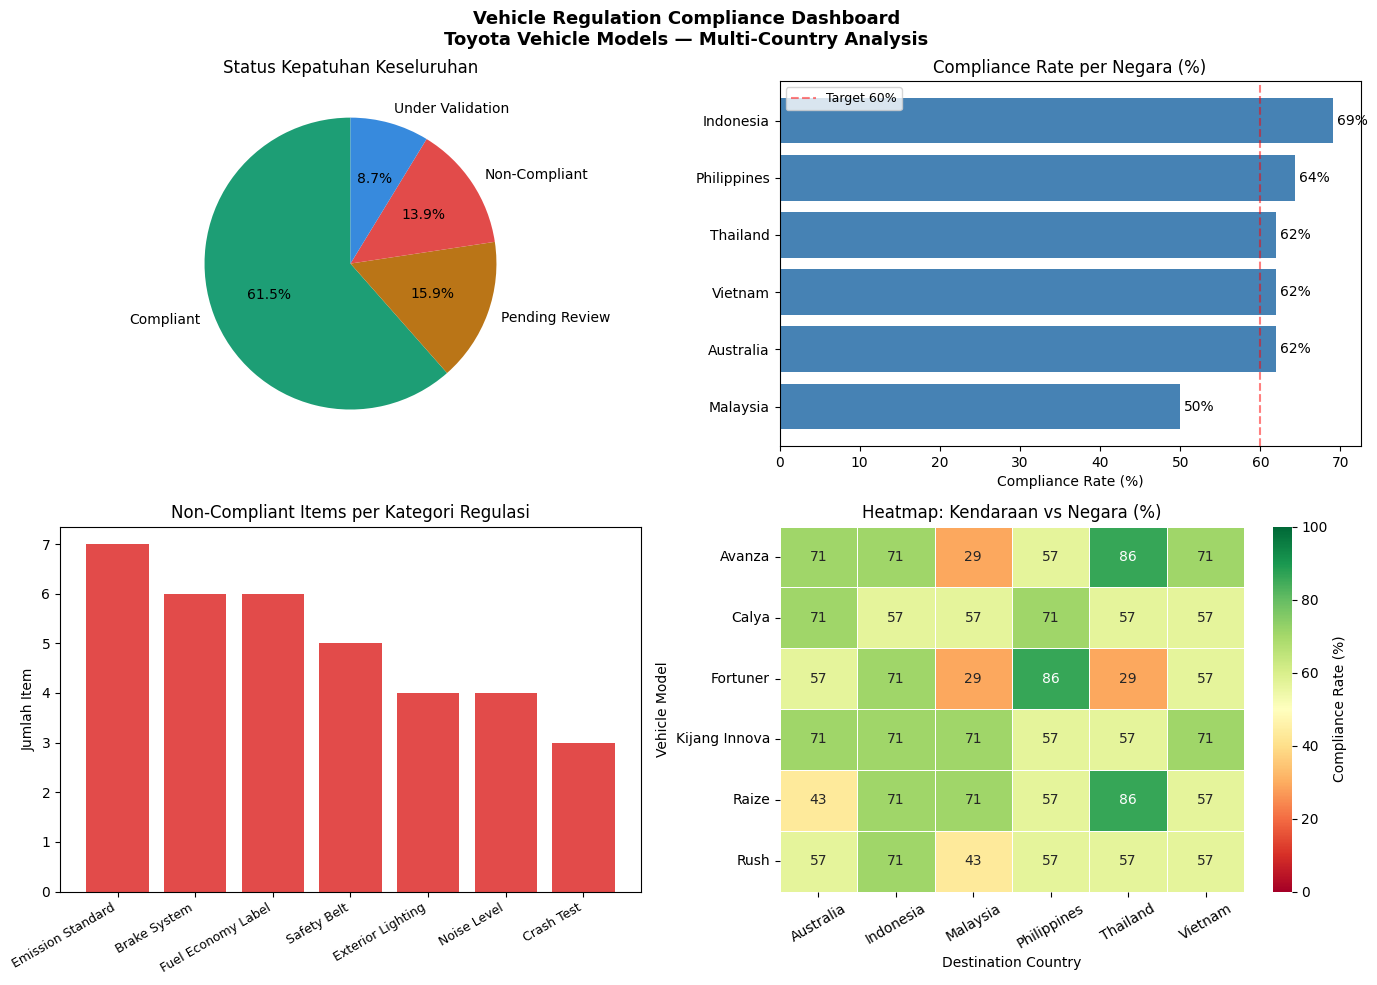

Grafik disimpan: compliance_dashboard.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Vehicle Regulation Compliance Dashboard\n'
             'Toyota Vehicle Models — Multi-Country Analysis',
             fontsize=13, fontweight='bold')

status_colors = {
    'Compliant'       : '#1D9E75',
    'Non-Compliant'   : '#E24B4A',
    'Pending Review'  : '#BA7517',
    'Under Validation': '#378ADD'
}

# Grafik 1: Pie chart — distribusi status keseluruhan
status_counts = df['Status'].value_counts()
colors_list   = [status_colors.get(s,'gray') for s in status_counts.index]
axes[0,0].pie(status_counts.values, labels=status_counts.index,
              autopct='%1.1f%%', colors=colors_list, startangle=90)
axes[0,0].set_title('Status Kepatuhan Keseluruhan')

# Grafik 2: Bar horizontal — compliance rate per negara
country_rate = (df[df['Status']=='Compliant'].groupby('Destination Country').size() /
                df.groupby('Destination Country').size() * 100).sort_values()
bars = axes[0,1].barh(country_rate.index, country_rate.values, color='steelblue')
axes[0,1].axvline(x=60, color='red', linestyle='--', alpha=0.5, label='Target 60%')
axes[0,1].set_title('Compliance Rate per Negara (%)')
axes[0,1].set_xlabel('Compliance Rate (%)')
axes[0,1].legend(fontsize=9)
for bar, val in zip(bars, country_rate.values):
    axes[0,1].text(val+0.5, bar.get_y()+bar.get_height()/2,
                   f'{val:.0f}%', va='center', fontsize=10)

# Grafik 3: Bar — non-compliant per kategori regulasi
nc_cat = df[df['Status']=='Non-Compliant'].groupby('Regulation Category').size().sort_values(ascending=False)
axes[1,0].bar(range(len(nc_cat)), nc_cat.values, color='#E24B4A')
axes[1,0].set_xticks(range(len(nc_cat)))
axes[1,0].set_xticklabels(nc_cat.index, rotation=30, ha='right', fontsize=9)
axes[1,0].set_title('Non-Compliant Items per Kategori Regulasi')
axes[1,0].set_ylabel('Jumlah Item')

# Grafik 4: Heatmap — compliance rate kendaraan vs negara
pivot = df[df['Status']=='Compliant'].groupby(
    ['Vehicle Model','Destination Country']).size().unstack(fill_value=0)
total_pivot = df.groupby(
    ['Vehicle Model','Destination Country']).size().unstack(fill_value=1)
rate_pivot = (pivot / total_pivot * 100).round(0)
sns.heatmap(rate_pivot, annot=True, fmt='.0f', ax=axes[1,1],
            cmap='RdYlGn', vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={'label':'Compliance Rate (%)'})
axes[1,1].set_title('Heatmap: Kendaraan vs Negara (%)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('compliance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: compliance_dashboard.png")

In [4]:
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment

output_file = 'Vehicle_Regulation_Compliance_Report.xlsx'

# Export 4 sheet
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:

    # Sheet 1: Data lengkap
    df.to_excel(writer, sheet_name='All Regulations', index=False)

    # Sheet 2: Item yang butuh tindakan segera
    df[df['Status']=='Non-Compliant'].reset_index(drop=True).to_excel(
        writer, sheet_name='Action Required', index=False)

    # Sheet 3: Summary per negara
    c_sum = df.groupby(['Destination Country','Status']).size().unstack(fill_value=0)
    c_sum['Total'] = c_sum.sum(axis=1)
    c_sum['Compliance Rate (%)'] = (c_sum.get('Compliant',0)/c_sum['Total']*100).round(1)
    c_sum.to_excel(writer, sheet_name='Country Summary')

    # Sheet 4: Summary per kendaraan
    v_sum = df.groupby(['Vehicle Model','Status']).size().unstack(fill_value=0)
    v_sum['Total'] = v_sum.sum(axis=1)
    v_sum['Compliance Rate (%)'] = (v_sum.get('Compliant',0)/v_sum['Total']*100).round(1)
    v_sum.to_excel(writer, sheet_name='Vehicle Summary')

# Tambahkan warna otomatis berdasarkan status
fill_colors = {
    'Compliant'       : 'C6EFCE',  # Hijau muda
    'Non-Compliant'   : 'FFC7CE',  # Merah muda
    'Pending Review'  : 'FFEB9C',  # Kuning
    'Under Validation': 'BDD7EE'   # Biru muda
}

wb = load_workbook(output_file)
ws = wb['All Regulations']

# Bold + center header
for cell in ws[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal='center')

# Temukan kolom Status, lalu warnai setiap baris
header = [cell.value for cell in ws[1]]
status_col = header.index('Status') + 1

for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
    status_val = row[status_col - 1].value
    if status_val in fill_colors:
        fill = PatternFill(start_color=fill_colors[status_val],
                          end_color=fill_colors[status_val],
                          fill_type='solid')
        for cell in row:
            cell.fill = fill

wb.save(output_file)

print(f"File Excel berhasil dibuat: {output_file}")
print("\nSheet yang tersedia:")
print("  1. All Regulations    — data lengkap dengan warna status otomatis")
print("  2. Action Required    — 30 item non-compliant yang perlu ditindaklanjuti")
print("  3. Country Summary    — compliance rate per negara")
print("  4. Vehicle Summary    — compliance rate per kendaraan")

File Excel berhasil dibuat: Vehicle_Regulation_Compliance_Report.xlsx

Sheet yang tersedia:
  1. All Regulations    — data lengkap dengan warna status otomatis
  2. Action Required    — 30 item non-compliant yang perlu ditindaklanjuti
  3. Country Summary    — compliance rate per negara
  4. Vehicle Summary    — compliance rate per kendaraan
